# import

In [690]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import my_module as my

***
# 0. Leitura e processamento inicial de dados

In [691]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [692]:
col_dict = my.format_columns(df)
df.head()

,ultimo,abertura,maxima,minima,vol,var
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [693]:
df.dtypes

ultimo      float64
abertura    float64
maxima      float64
minima      float64
vol          object
var          object
dtype: object

## Tratamento e formatação de valores

In [694]:
# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M","1,45%"
2025-06-27,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
2025-06-26,137.114,135.767,137.353,135.756,"8,02B","0,99%"
2025-06-25,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
2025-06-24,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [695]:
# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M",1.45
2025-06-27,136.866,137.113,137.209,136.469,"6,24B",-0.18
2025-06-26,137.114,135.767,137.353,135.756,"8,02B",0.99
2025-06-25,135.767,137.163,137.163,135.565,"7,71B",-1.02
2025-06-24,137.165,136.552,138.156,136.254,"8,08B",0.45


In [696]:
# Ordenando nosso index
df = df.sort_index()
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.28
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",1.79
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.89
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.08
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-4.73


In [697]:
# Retirando colunas irrelevantes
df = df.drop(['maxima','minima', 'abertura', 'vol'], axis=1)
df.head()

,ultimo,var
data,,
2010-01-29,65.402,-0.28
2010-02-01,66.572,1.79
2010-02-02,67.163,0.89
2010-02-03,67.109,-0.08
2010-02-04,63.934,-4.73


In [698]:
def make_alta(df : pd.DataFrame, from_column : str = 'var'):
    df['alta'] = False
    df.loc[df['var'] > 0, 'alta'] = True
    return df

In [699]:
df = make_alta(df)
df

,ultimo,var,alta
data,,,
2010-01-29,65.402,-0.28,False
2010-02-01,66.572,1.79,True
2010-02-02,67.163,0.89,True
2010-02-03,67.109,-0.08,False
2010-02-04,63.934,-4.73,False
...,...,...,...
2025-06-24,137.165,0.45,True
2025-06-25,135.767,-1.02,False
2025-06-26,137.114,0.99,True


# 1. Análise inicial

In [700]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [701]:
sns.set_style('darkgrid')

In [702]:
studied = 'var'
target = 'alta'

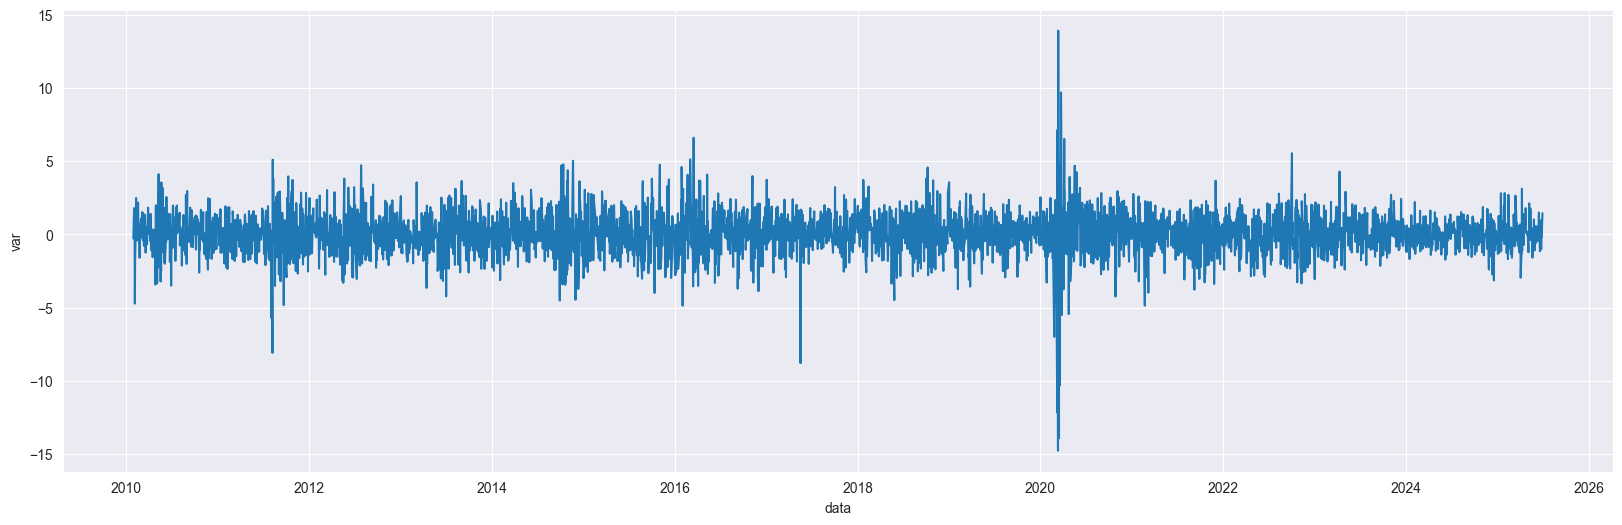

In [703]:
fig = plt.figure(figsize=(20,6))
sns.lineplot(
    df[studied]
);

## Dados originais

#### import

In [704]:
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### functions

In [705]:
def seasonality_search(df : pd.DataFrame, column : str, mask):
    results = []
    for p in range(2, 31):
        result = seasonal_decompose(
            df[column].loc[mask],
            model = 'additive',
            period = p
        )

        results.append((p, abs(result.resid.mean())))

    results.sort(key = lambda x: x[1])
    return results

## Var

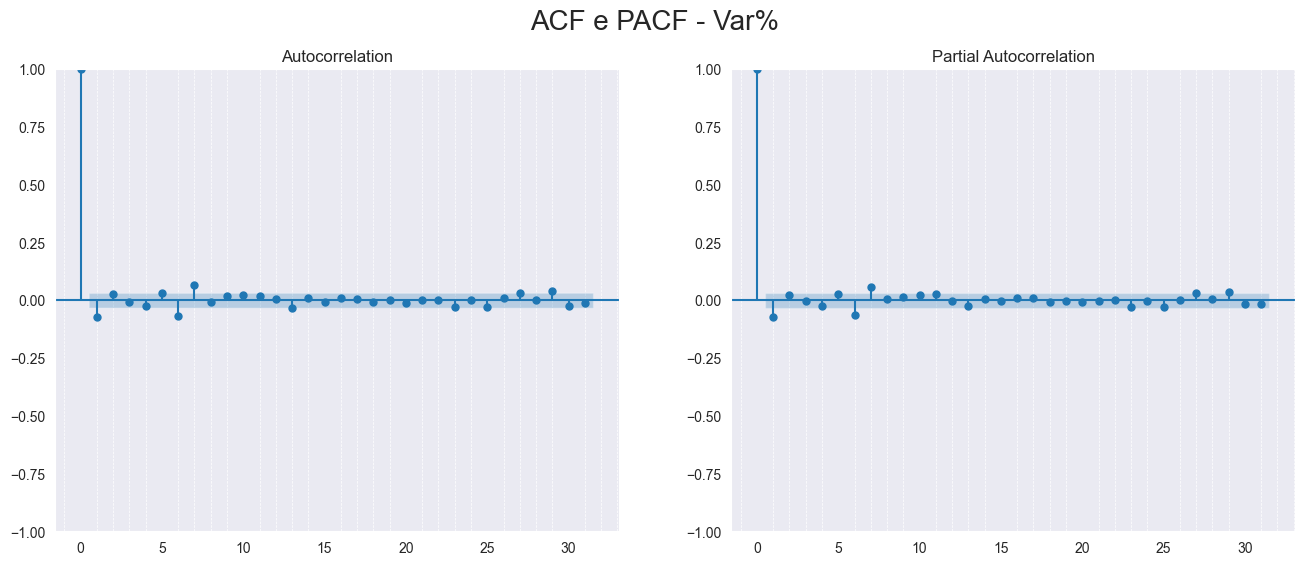

In [706]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


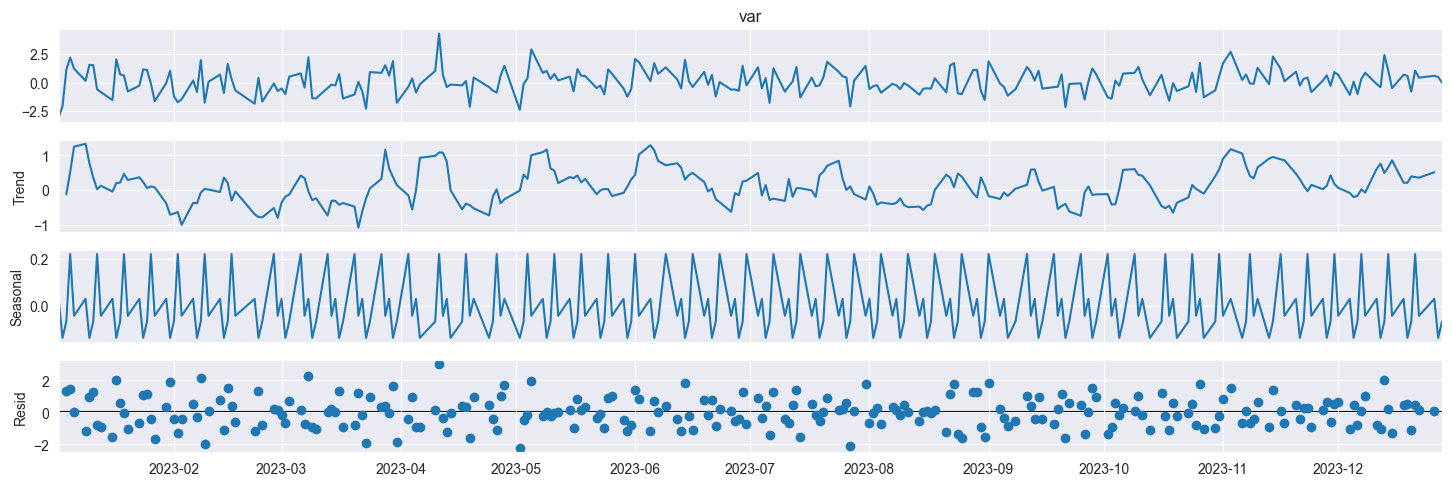

In [707]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[studied].loc[mask],
    model = 'additive',
    period = 5
).plot();

fig.set_size_inches(16, 5)

In [708]:
results = seasonality_search(df, studied, mask)

results[:10]

[(26, np.float64(0.00017659023668641321)),
 (12, np.float64(0.00020413011695909317)),
 (13, np.float64(0.0005368697878819161)),
 (20, np.float64(0.0005551136363636108)),
 (8, np.float64(0.0006093749999999639)),
 (9, np.float64(0.0009982061833913518)),
 (2, np.float64(0.0015040650406504034)),
 (3, np.float64(0.0020054200542005524)),
 (19, np.float64(0.002006534555011016)),
 (21, np.float64(0.00221521335807048))]

0.5203675396231702 -0.0008544740522706817


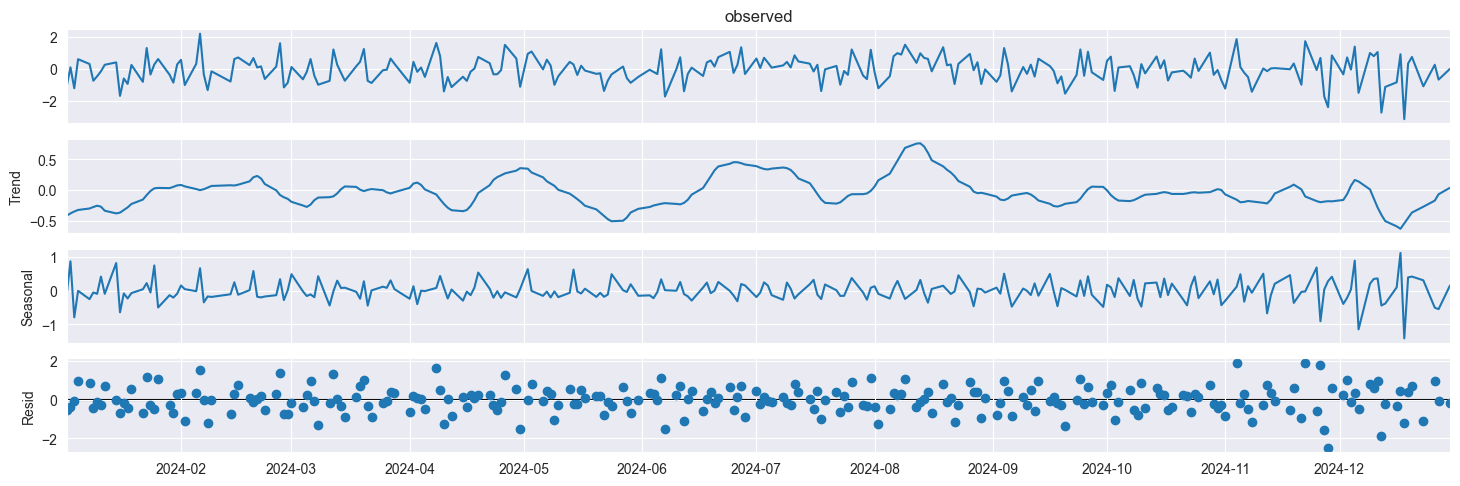

In [709]:
year = 2024
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))

mstl = MSTL(
    df[studied].loc[mask],
    periods = [8])
mstl_fit = mstl.fit()

fig = mstl_fit.plot()

fig.set_size_inches(16, 5)

print(mstl_fit.resid.abs().mean(), mstl_fit.resid.mean())

## Alta e baixa

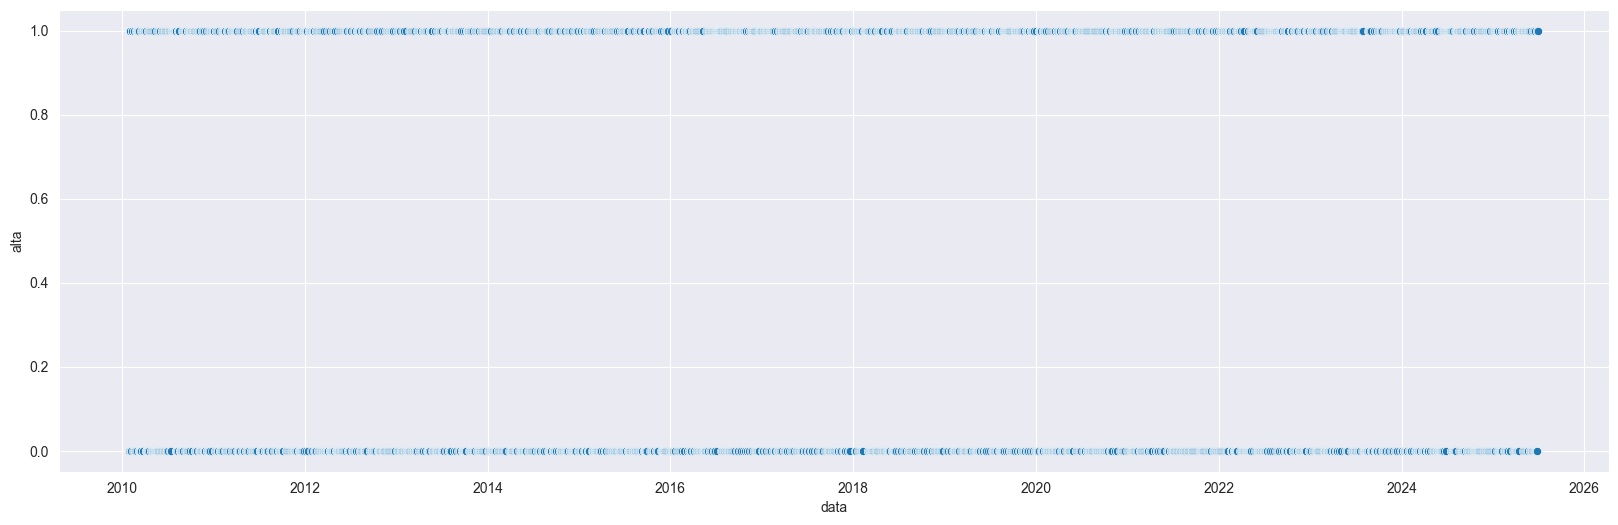

In [710]:
fig = plt.figure(figsize=(20,6))
sns.scatterplot(
    df[target]
);

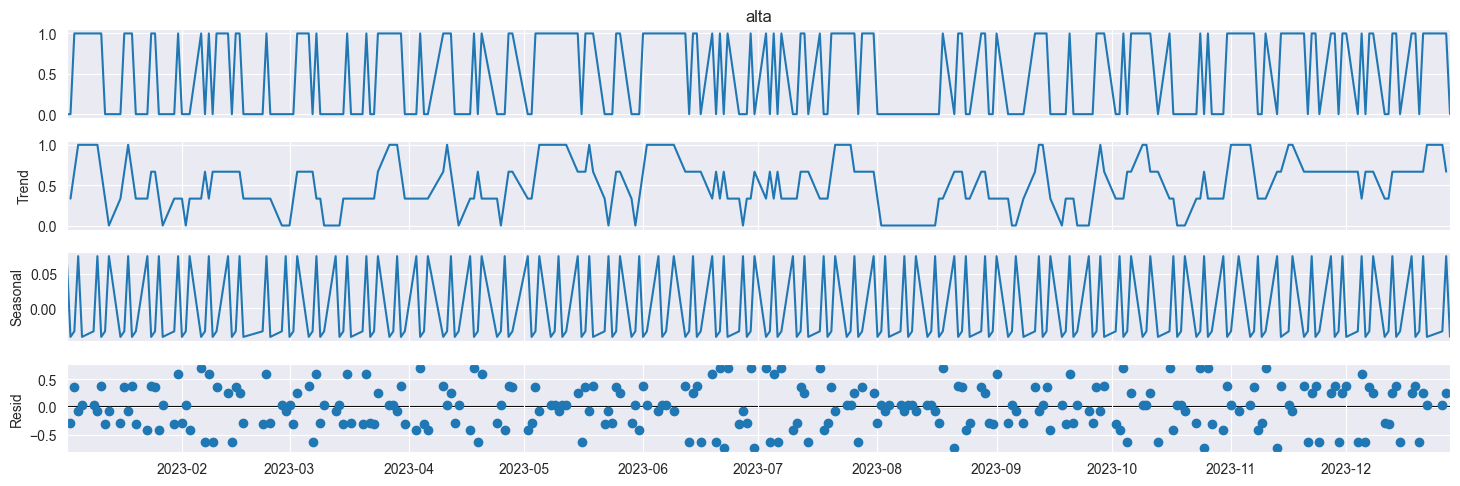

In [711]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[target].loc[mask],
    model = 'additive',
    period = 3
).plot();

fig.set_size_inches(16, 5)

In [712]:
results = seasonality_search(df, target, mask)
results[:10]

[(8, np.float64(1.8503717077085942e-18)),
 (25, np.float64(0.00011111111111111688)),
 (9, np.float64(0.0002286236854138294)),
 (27, np.float64(0.0002667276329828249)),
 (2, np.float64(0.0010162601626016279)),
 (20, np.float64(0.0011363636363636897)),
 (13, np.float64(0.0012630194816429796)),
 (3, np.float64(0.001355013550135527)),
 (22, np.float64(0.0013711495116453547)),
 (6, np.float64(0.0016514227642276708))]

## Ultimo


In [713]:
studied = 'ultimo'

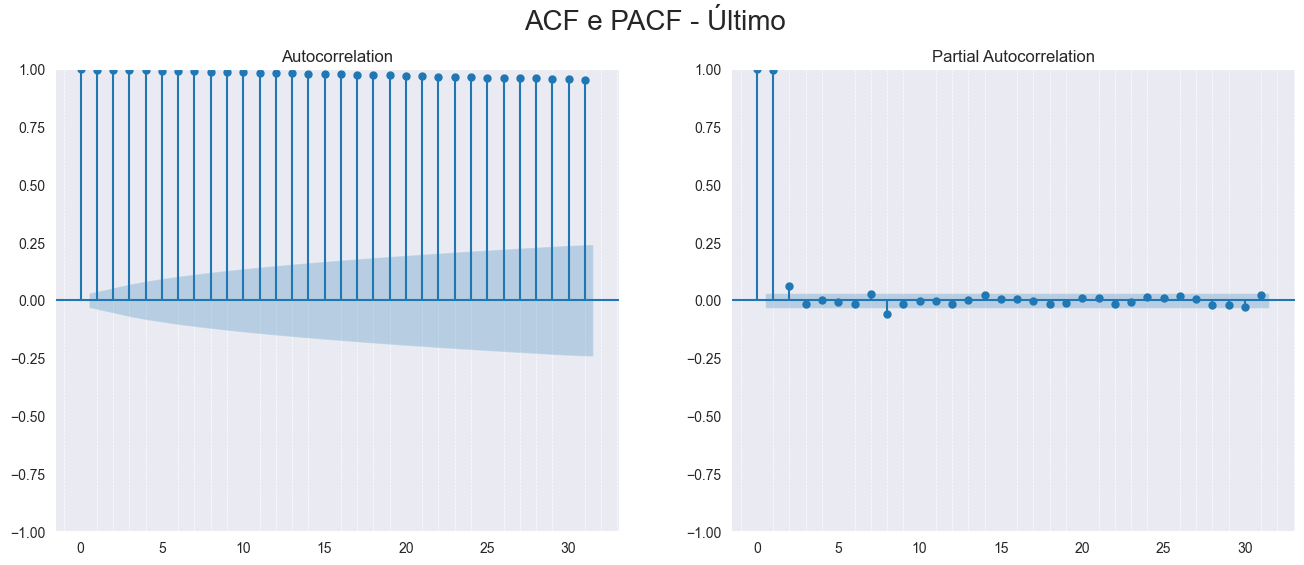

In [714]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


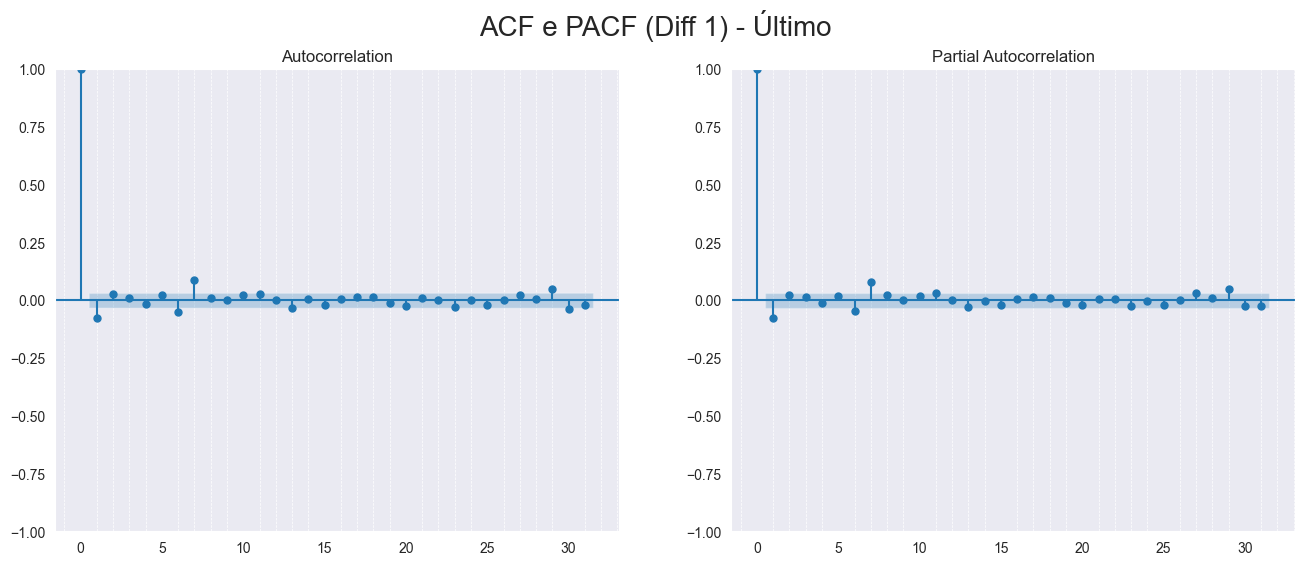

In [715]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF (Diff 1) - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied].diff().iloc[1:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied].diff().iloc[1:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


In [716]:
results = seasonality_search(df, studied, mask)
results [:10]

[(5, np.float64(0.00048782312924364966)),
 (4, np.float64(0.0006936475409834496)),
 (2, np.float64(0.0022367886178864278)),
 (9, np.float64(0.002942650627843461)),
 (3, np.float64(0.0029823848238410638)),
 (16, np.float64(0.0039818638392868115)),
 (6, np.float64(0.005313338414641539)),
 (14, np.float64(0.005573416866753862)),
 (7, np.float64(0.006171634368039723)),
 (8, np.float64(0.006917447916665701))]

0.521502791484965 0.002622169994078906


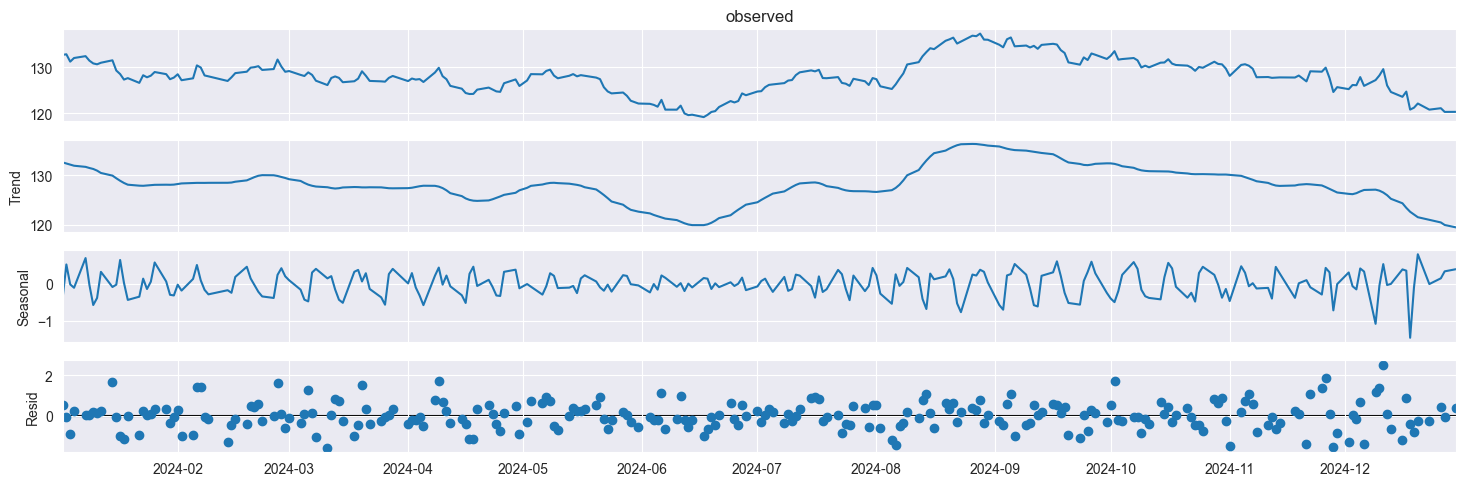

In [717]:
year = 2024
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))

mstl = MSTL(
    df[studied].loc[mask],
    periods = [7])
mstl_fit = mstl.fit()

fig = mstl_fit.plot()

fig.set_size_inches(16, 5)

print(mstl_fit.resid.abs().mean(), mstl_fit.resid.mean())

In [718]:
# Retirando colunas ultimo
df = df.drop(['ultimo'], axis=1)
df.head()

,var,alta
data,,
2010-01-29,-0.28,False
2010-02-01,1.79,True
2010-02-02,0.89,True
2010-02-03,-0.08,False
2010-02-04,-4.73,False


***
# 2. Modelo Baseline

### functions

In [719]:
models = {}

In [720]:
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, roc_auc_score

def add_metrics_categorical(
        model_name : str,
        y_pred,
        y_true,
        y_prob = None
):
    models[model_name]['metrics'] = {}
    models[model_name]['metrics']['accuracy'] = accuracy_score(y_true, y_pred)
    models[model_name]['metrics']['precision'] = precision_score(y_true, y_pred)
    models[model_name]['metrics']['recall'] = recall_score(y_true, y_pred)
    if y_prob != None:
        models[model_name]['metrics']['roc_auc'] = roc_auc_score(y_true, y_prob)

In [721]:
def print_metrics_categorical(
        y_pred,
        y_true,
        y_prob = None
):
    print(f'ACCURACY\t{accuracy_score(y_true, y_pred):4f}\tPRECISION\t{precision_score(y_true, y_pred):4f}\tRECALL\t{recall_score(y_true, y_pred):4f}')
    
    if y_prob != None:
        print(f'ROC AUC\t{roc_auc_score(y_true, y_prob)}')

In [722]:
# Chance de ter alta no final do dia

pred_prob = df[target].value_counts() / df[target].value_counts().sum()
pred_prob = pred_prob[True]
pred_prob

np.float64(0.5116461659251504)

In [723]:
# Quantos dias vamos prever

n_predictions = 30

In [724]:
# Ultimos 30 dias reais
y_true = y.iloc[-30:]
y_true

3791     True
3792     True
3793    False
3794    False
3795     True
3796     True
3797     True
3798    False
3799    False
3800    False
3801    False
3802     True
3803    False
3804    False
3805    False
3806    False
3807     True
3808     True
3809     True
3810    False
3811     True
3812    False
3813    False
3814    False
3815    False
3816     True
3817    False
3818     True
3819    False
3820     True
Name: alta, dtype: bool

## Baseline

In [725]:
from sklearn.model_selection import KFold# , TimeSeriesSplit

kf_params = {
    'splits': 10,
    'shuffle': True,
    'random_state': SEED
}

kf = KFold(
    n_splits = kf_params['splits'],
    shuffle = kf_params['shuffle'],
    random_state = kf_params['random_state']
)

# kft = TimeSeriesSplit(
#     n_splits = kf_params['splits']
# )

In [726]:
SEED = 152
np.random.seed(SEED)

y_pred = []

for i in range(0, n_predictions):
    roll = np.random.random()
    
    if roll < pred_prob:
        y_pred += [True]
    else:
        y_pred += [False]

models['baseline'] = {
    'params': {}
}

add_metrics_categorical(
    'baseline',
    y_pred,
    y_true
)

models['baseline']['metrics']

{'accuracy': 0.4,
 'precision': 0.3684210526315789,
 'recall': 0.5384615384615384}

***
# 3. Modelos Classificadores

## Shifts numéricos

In [727]:
df_class1 = df.copy().reset_index()

shift = [x for x in range(1, 30 + 1)]

for i in shift:
    new_col = f'shift_{i}'

    df_class1[new_col] = df_class1['var'].shift(i)

## Shifts booleanos

In [728]:
shift = [x for x in range(1, 30 + 1)]

for i in shift:
    new_col = f'shift_bool_{i}'

    df_class1[new_col] = df_class1['alta'].shift(i)


## Médias móveis

In [729]:
ma = [x for x in range(1, 15 + 1)]

for i in ma:
    new_col = f'ma_{i}'

    df_class1[new_col] = df_class1['var'].rolling(i).mean()


## std

In [730]:
ma = [x for x in range(1, 7+1)]

for i in ma:
    new_col = f'std_{i}'

    df_class1[new_col] = df_class1['var'].rolling(i).std()


## Diferenças

## Modelos

In [731]:
df_class1 = df_class1.drop('var',axis=1)

In [ ]:
# params = ['shift_1', 'shift_2', 'shift_3', 'shift_4', 'shift_5', 'shift_6', 'shift_7', 'ma_7', 'std_7'] Saved
params = ['shift_1', 'shift_2', 'shift_3', 'shift_4', 'shift_5', 'shift_6', 'shift_7', 'ma_7', 'std_7']
df_class1 = df_class1.loc[30:]
df_class1[['alta'] + params]

,alta,shift_1,shift_2,shift_3,shift_4,shift_5,shift_6,shift_7,ma_7,std_7
30,True,-0.46,-0.78,-0.13,0.58,1.46,-0.39,1.52,0.230000,0.899593
31,False,1.33,-0.46,-0.78,-0.13,0.58,1.46,-0.39,0.241429,0.890869
32,False,-0.31,1.33,-0.46,-0.78,-0.13,0.58,1.46,0.027143,0.711189
33,False,-0.04,-0.31,1.33,-0.46,-0.78,-0.13,0.58,-0.234286,0.804339
34,True,-1.25,-0.04,-0.31,1.33,-0.46,-0.78,-0.13,-0.171429,0.830611
...,...,...,...,...,...,...,...,...,...,...
3816,True,-0.41,-1.15,-0.09,-0.30,1.49,-0.43,0.49,-0.062857,0.833521
3817,False,0.45,-0.41,-1.15,-0.09,-0.30,1.49,-0.43,-0.147143,0.903709
3818,True,-1.02,0.45,-0.41,-1.15,-0.09,-0.30,1.49,-0.218571,0.761280
3819,False,0.99,-1.02,0.45,-0.41,-1.15,-0.09,-0.30,-0.201429,0.760492


In [733]:
y = df_class1['alta']
x = df_class1[params]

In [734]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.25,
    random_state = SEED,
    stratify = y
)

### Logistic Regression

In [735]:
from sklearn.linear_model import LogisticRegression

current_model = 'kneighborsclassifier1'
models[current_model] = {}

acc = {}

for solver in ['lbfgs','sag','saga','newton-cg','liblinear']:
    model = LogisticRegression(
        random_state = SEED,
        solver = solver
    )

    model.fit(x_train, y_train)
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[solver] = (test_score, train_score)
acc

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'lbfgs': (0.9926160337552743, 0.9947238832219486),
 'sag': (0.989451476793249, 0.9943721421034118),
 'saga': (0.9862869198312236, 0.9897995075624341),
 'newton-cg': (0.9926160337552743, 0.9947238832219486),
 'liblinear': (0.9926160337552743, 0.9947238832219486)}

#### Cross Validation


In [740]:
def validate_logistic_regression(
        x,
        y,
        solver,
        random_state = SEED
):
    fold = 1
    for train_idx, test_idx in kf.split(x, y):
        model = LogisticRegression(
            solver = solver,
            random_state = random_state
        )

        x_train = x.iloc[train_idx]
        y_train = y.iloc[train_idx]

        x_test = x.iloc[test_idx]
        y_test = y.iloc[test_idx]

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        
        print(f'============= FOLD {fold} =============')
        print(f'Train {len(y_train)} | Test {len(y_test)}')

        print_metrics_categorical(y_test, y_pred)

        fold +=1

In [739]:
validate_logistic_regression(
    x,
    y,
    solver = 'lbfgs'
)

============= FOLD 0 =============
Train 3411 | Test 380
ACCURACY	0.994737	PRECISION	1.000000	RECALL	0.990950
============= FOLD 1 =============
Train 3412 | Test 379
ACCURACY	0.994723	PRECISION	0.994536	RECALL	0.994536
============= FOLD 2 =============
Train 3412 | Test 379
ACCURACY	0.997361	PRECISION	0.994924	RECALL	1.000000
============= FOLD 3 =============
Train 3412 | Test 379
ACCURACY	0.992084	PRECISION	1.000000	RECALL	0.985222
============= FOLD 4 =============
Train 3412 | Test 379
ACCURACY	0.994723	PRECISION	0.994872	RECALL	0.994872
============= FOLD 5 =============
Train 3412 | Test 379
ACCURACY	0.986807	PRECISION	0.988095	RECALL	0.982249
============= FOLD 6 =============
Train 3412 | Test 379
ACCURACY	0.992084	PRECISION	0.994737	RECALL	0.989529
============= FOLD 7 =============
Train 3412 | Test 379
ACCURACY	0.981530	PRECISION	0.994975	RECALL	0.970588
============= FOLD 8 =============
Train 3412 | Test 379
ACCURACY	0.989446	PRECISION	1.000000	RECALL	0.978022
==========

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

current_model = 'kneighborsclassifier1'
models[current_model] = {}

acc = {}

min_n = 3
max_n = 20

for n in range(min_n, max_n+1):  
    model = KNeighborsClassifier(
        n_neighbors = n
    )

    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[n] = (test_score, train_score)
acc

{3: (0.5263713080168776, 0.7759409074920858),
 4: (0.5189873417721519, 0.7143862117481533),
 5: (0.5253164556962026, 0.7277523742525501),
 6: (0.5253164556962026, 0.6936334857544847),
 7: (0.5305907172995781, 0.6915230390432642),
 8: (0.509493670886076, 0.6823777699613085),
 9: (0.5369198312236287, 0.681674287724235),
 10: (0.5253164556962026, 0.6658459373900809),
 11: (0.5284810126582279, 0.659866338374956),
 12: (0.5316455696202531, 0.6559971860710517),
 13: (0.5369198312236287, 0.6588111150193457),
 14: (0.5263713080168776, 0.6510728104115371),
 15: (0.5284810126582279, 0.6514245515300738),
 16: (0.5316455696202531, 0.6436862469222652),
 17: (0.5474683544303798, 0.6521280337671473),
 18: (0.5348101265822784, 0.6517762926486106),
 19: (0.5537974683544303, 0.645444952514949),
 20: (0.5453586497890295, 0.6443897291593387)}

### RandomForestClassifier 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
current_model = 'randomforestclassifier1'
models[current_model] = {}

acc = {}

min_depth = 2
max_depth = 15

for depth in range(min_depth, max_depth+1):
    model = RandomForestClassifier(
        n_estimators = 100,
        max_depth = depth,
        random_state = SEED
    )

    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[depth] = (test_score, train_score)
acc

{2: (0.5981012658227848, 0.6377066479071404),
 3: (0.5949367088607594, 0.6507210692930003),
 4: (0.6160337552742616, 0.6806190643686247),
 5: (0.6434599156118144, 0.7323250087935279),
 6: (0.6687763713080169, 0.7847344354555047),
 7: (0.6645569620253164, 0.8410130144213859),
 8: (0.6888185654008439, 0.8934224410833627),
 9: (0.7014767932489452, 0.9426661976785086),
 10: (0.7088607594936709, 0.9743228983468167),
 11: (0.7141350210970464, 0.9922616953921913),
 12: (0.7141350210970464, 0.9992965177629265),
 13: (0.7141350210970464, 1.0),
 14: (0.7257383966244726, 1.0),
 15: (0.7320675105485233, 1.0)}

#### Cross-Validation

In [ ]:
def validate_randomforest(
        x,
        y,
        n_estimators,
        max_depth,
        random_state = SEED
):
    for train_idx, test_idx in kf.split(x ,y):
        model = RandomForestClassifier(
            n_estimators = n_estimators,
            max_depth = max_depth,
            random_state = random_state
        )

        x_train = x.iloc[train_idx]
        y_train = y.iloc[train_idx]

        x_test = x.iloc[test_idx]
        y_test = y.iloc[test_idx]

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        
        print(f'============= FOLD {fold} =============')
        print(f'Train {len(y_train)} | Test {len(y_test)}')

        print_metrics_categorical(y_test, y_pred)

        fold +=1

In [ ]:
# current_model = 'randomforestclassifier1'
# models[current_model] = {}
# models[current_model]['params'] = {
#     'n_estimators':100,
#     'max_depth':20
# }

# fold = 1
# for train_idx, test_idx in kf.split(x ,y):
#     model = RandomForestClassifier(
#         n_estimators = models[current_model]['params']['n_estimators'],
#         max_depth = models[current_model]['params']['max_depth'],
#         random_state = SEED
#     )

#     x_train = x.iloc[train_idx]
#     y_train = y.iloc[train_idx]

#     x_test = x.iloc[test_idx]
#     y_test = y.iloc[test_idx]

#     model.fit(x_train, y_train)

#     y_pred = model.predict(x_test)
    
#     print(f'============= FOLD {fold} =============')
#     print(f'Train {len(y_train)} | Test {len(y_test)}')

#     print_metrics_categorical(y_test, y_pred)

#     fold +=1

***
# 4. Modelos Time Series

## ARIMA

### import